In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('daily-power-generation.csv', parse_dates=['date'])
print(df.shape)
df.head()

(2583818, 12)


,id,date,region,state_name,state_code,sector,station_type,power_station,power_station_unit,monitored_capacity,todays_gen_prgm,todays_gen_act
0,1,2017-09-01,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 1,67.5,0.00,0.00
1,2,2017-09-01,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 2,67.5,0.00,0.00
2,3,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),I.P.Ccpp,Single Unit,270.0,1.80,0.87
3,4,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccgt-Iii,Single Unit,1500.0,6.00,10.89
4,5,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccpp,Single Unit,330.4,5.49,6.53


In [3]:
duplicates = df.duplicated(subset = ['date', 'power_station', 'power_station_unit'])
print('No. of duplicates: ', duplicates.sum())
print('Before dropping duplicates: ',len(df))
df = df.drop_duplicates(subset = ['date', 'power_station', 'power_station_unit'])
print('After dropping duplicates: ', len(df))

No. of duplicates:  42
Before dropping duplicates:  2583818
After dropping duplicates:  2583776


In [4]:
bhutan_import = df[df['region'] == 'Bhutan Imp.'].copy()
print('Bhutan import count: ', len(bhutan_import))
print('Before removing bhutan imprt: ', len(df))
df = df[df['region'] != 'Bhutan Imp.'].copy()
print('After removing bhutan improt: ', len(df))

Bhutan import count:  12645
Before removing bhutan imprt:  2583776
After removing bhutan improt:  2571131


In [5]:
df['capacity_reported'] = df['monitored_capacity'].notna() & df['monitored_capacity']>0
print(f"Rows with unreliable capacity (flagged, not dropped): {(~df['capacity_reported']).sum()}")

Rows with unreliable capacity (flagged, not dropped): 161356


In [6]:
# shortfall = planned generation - actual generation
df['shortfall'] = df['todays_gen_prgm'] - df['todays_gen_act']
df['shortfall_pct'] = np.where(
    df['todays_gen_prgm'] > 0,
    (df['shortfall'] / df['todays_gen_prgm']) * 100,
    np.nan
)
df.head(10)

,id,date,region,state_name,state_code,sector,station_type,power_station,power_station_unit,monitored_capacity,todays_gen_prgm,todays_gen_act,capacity_reported,shortfall,shortfall_pct
0,1,2017-09-01,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 1,67.5,0.00,0.00,True,0.00,NaN
1,2,2017-09-01,Northern,Delhi,7.0,State,Thermal,Rajghat Tps,Unit 2,67.5,0.00,0.00,True,0.00,NaN
2,3,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),I.P.Ccpp,Single Unit,270.0,1.80,0.87,True,0.93,51.666667
3,4,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccgt-Iii,Single Unit,1500.0,6.00,10.89,True,-4.89,-81.500000
4,5,2017-09-01,Northern,Delhi,7.0,State,Ther (Gt),Pragati Ccpp,Single Unit,330.4,5.49,6.53,True,-1.04,-18.943534
5,6,2017-09-01,Northern,Delhi,7.0,Private,Ther (Gt),Rithala Ccpp,Single Unit,108.0,0.00,0.00,True,0.00,NaN
6,7,2017-09-01,Northern,Delhi,7.0,Central,Thermal,Badarpur Tps,Unit 1,95.0,0.00,0.00,True,0.00,NaN
7,8,2017-09-01,Northern,Delhi,7.0,Central,Thermal,Badarpur Tps,Unit 2,95.0,0.00,0.00,True,0.00,NaN
8,9,2017-09-01,Northern,Delhi,7.0,Central,Thermal,Badarpur Tps,Unit 3,95.0,0.00,0.00,True,0.00,NaN
9,10,2017-09-01,Northern,Delhi,7.0,Central,Thermal,Badarpur Tps,Unit 4,210.0,2.90,4.14,True,-1.24,-42.758621


In [7]:
print('Station Types: ', df['station_type'].dropna().unique().tolist())

Station Types:  ['Thermal', 'Ther (Gt)', 'Hydro', 'Nuclear', 'Ther (Dg)']


In [8]:
df['year_month'] = df['date'].dt.to_period('M')
state_monthly = df.groupby(['state_name', 'year_month']).agg(
    total_prgm = ('todays_gen_prgm', 'sum'),
    total_act = ('todays_gen_act', 'sum'),
    total_shortfall = ('shortfall', 'sum'),
    no_of_units = ('power_station_unit', 'nunique')
).reset_index()

In [9]:
state_monthly['shortfall_pct_of_planned'] = np.where(
    state_monthly['total_prgm'] > 0,
    (state_monthly['total_shortfall'] / state_monthly['total_prgm']) * 100,
    np.nan
)
print(f"\nState-month aggregate shape: {state_monthly.shape}")


State-month aggregate shape: (2937, 7)


In [10]:
statetype_monthly = df.groupby(['state_name', 'station_type', 'year_month']).agg(
    total_prgm = ('todays_gen_prgm', 'sum'),
    total_act = ('todays_gen_act', 'sum'),
    total_shortfall = ('shortfall', 'sum'),
).reset_index()
statetype_monthly['shortfall_pct_of_planned'] = np.where(
    statetype_monthly['total_prgm'] > 0,
    (statetype_monthly['total_shortfall'] / statetype_monthly['total_prgm']) * 100,
    np.nan
)
print(f"\nStatetype-month aggregate shape: {statetype_monthly.shape}")


Statetype-month aggregate shape: (6432, 7)


  year_month  total_prgm  total_act  total_shortfall  shortfall_pct
0    2017-09   103504.87   99282.95          4221.92       4.078958
1    2017-10    97389.36   95631.42          1757.94       1.805064
2    2017-11    95158.45   94886.12           272.33       0.286186
3    2017-12    98019.33   96494.84          1524.49       1.555295
4    2018-01   100535.08  101109.54          -574.46      -0.571403


<Figure size 1200x700 with 0 Axes>

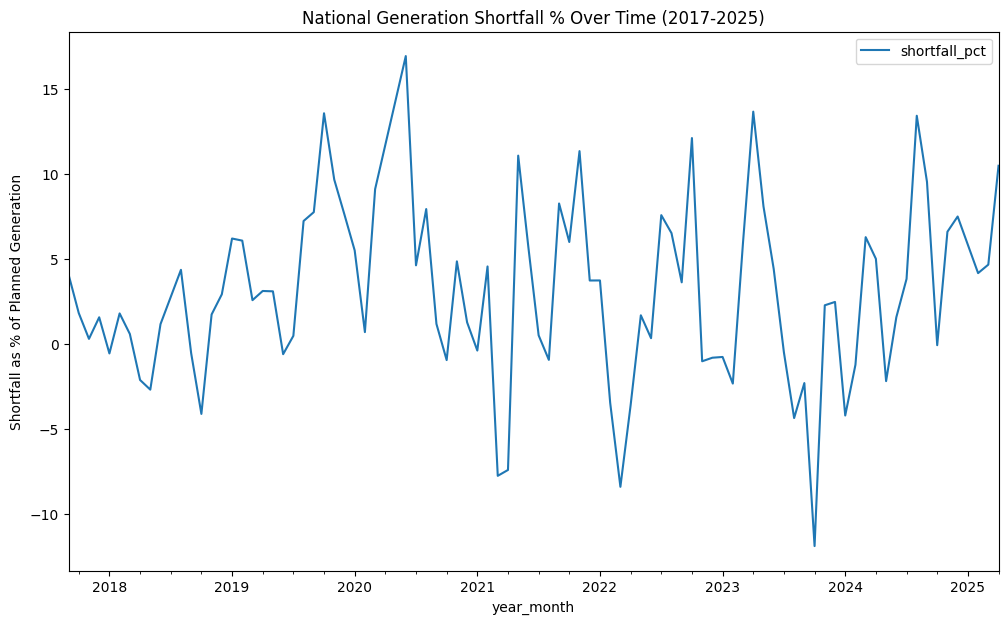

In [11]:
national = state_monthly.groupby('year_month').agg(
    total_prgm = ('total_prgm', 'sum'),
    total_act = ('total_act', 'sum'),
    total_shortfall = ('total_shortfall', 'sum'),
).reset_index()

national['shortfall_pct'] = (national['total_shortfall'] / national['total_prgm']) * 100
print(national.head())

plt.figure(figsize=(12,7))
national.plot(x='year_month', y='shortfall_pct', figsize=(12,7))
plt.title('National Generation Shortfall % Over Time (2017-2025)')
plt.ylabel('Shortfall as % of Planned Generation')
plt.show()

In [12]:
print("=== INSIGHT 1: National trend (planned vs. actual generation) ===")
first_period = national.head(12)['shortfall_pct'].mean()
last_period = national.tail(12)['shortfall_pct'].mean()
print(f"Avg deviation from plan - first 12 months: {first_period:.2f}%")
print(f"Avg deviation from plan - last 12 months:  {last_period:.2f}%")
print(f"-> Net under-delivery relative to planned generation "
      f"{'increased' if last_period > first_period else 'decreased'} over the observed period\n")

=== INSIGHT 1: National trend (planned vs. actual generation) ===
Avg deviation from plan - first 12 months: 1.08%
Avg deviation from plan - last 12 months:  5.36%
-> Net under-delivery relative to planned generation increased over the observed period



In [13]:
latest = state_monthly['year_month'].max()
recent_cutoff = latest - 11
recent = state_monthly[state_monthly['year_month'] >= recent_cutoff]

state_recent_reliability = recent.groupby('state_name').agg(
    total_prgm = ('total_prgm', 'sum'),
    total_act = ('total_act', 'sum'),
    total_shortfall = ('total_shortfall', 'sum'),
).reset_index()
state_recent_reliability['shortfall_pct'] = (state_recent_reliability['total_shortfall'] / state_recent_reliability['total_prgm']) * 100

In [14]:
MIN_PRGM_THRESHOLD = state_recent_reliability['total_prgm'].quantile(0.25)
material_states = state_recent_reliability[
    state_recent_reliability['total_prgm'] >= MIN_PRGM_THRESHOLD
].copy()

worst_5 = material_states.sort_values('shortfall_pct', ascending=False).head(5)
best_5 = material_states.sort_values('shortfall_pct', ascending=True).head(5)

print("=== INSIGHT 2: Least reliable states (last 12 months, material generation only) ===")
print(worst_5[['state_name', 'shortfall_pct', 'total_prgm']].to_string(index=False))
print("\n=== Most reliable states (last 12 months) ===")
print(best_5[['state_name', 'shortfall_pct', 'total_prgm']].to_string(index=False))
print()

=== INSIGHT 2: Least reliable states (last 12 months, material generation only) ===
       state_name  shortfall_pct  total_prgm
            Delhi      26.174266     4968.85
           Sikkim      24.913094     2488.33
          Tripura      21.855450     5361.18
Jammu And Kashmir      16.873975    15644.98
        Telangana      15.431681    61400.83

=== Most reliable states (last 12 months) ===
 state_name  shortfall_pct  total_prgm
    Gujarat      -7.042402    86181.67
Uttarakhand      -1.923618    13867.62
     Punjab      -0.828781    31587.34
Chhatisgarh      -0.441688   135274.12
  Rajasthan       0.109258    60636.55



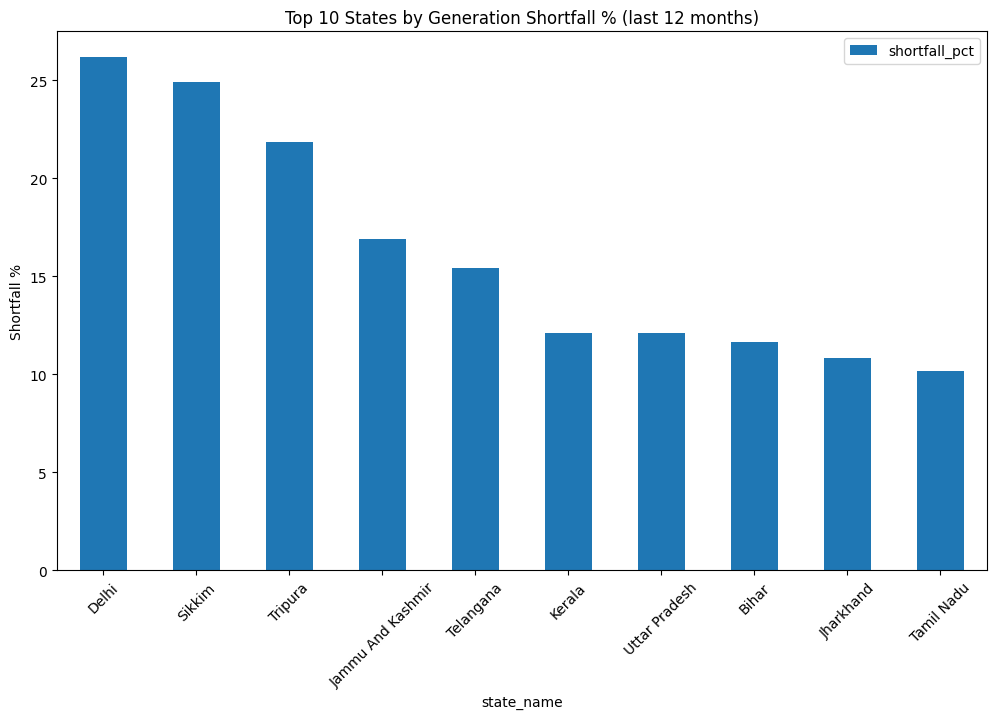

In [15]:
top_shortfall = material_states.sort_values('shortfall_pct', ascending=False).head(10)
top_shortfall.plot(kind='bar', x='state_name', y='shortfall_pct', figsize=(12,7))
plt.title('Top 10 States by Generation Shortfall % (last 12 months)')
plt.ylabel('Shortfall %')
plt.xticks(rotation=45)
plt.show()

In [16]:
source_reliability = statetype_monthly.groupby('station_type').agg(
    total_prgm = ('total_prgm', 'sum'),
    total_act = ('total_act', 'sum'),
    total_shortfall = ('total_shortfall', 'sum'),
).reset_index()
source_reliability['shortfall_pct'] = (source_reliability['total_shortfall'] / source_reliability['total_prgm']) * 100

print("=== INSIGHT 3: Reliability by generation source type (2017-2025) ===")
source_reliability = source_reliability.sort_values('shortfall_pct', ascending=False)
print(source_reliability.to_string(index=False))
print()

=== INSIGHT 3: Reliability by generation source type (2017-2025) ===
station_type  total_prgm  total_act  total_shortfall  shortfall_pct
   Ther (Gt)   310815.47  289376.71         21438.76       6.897585
     Thermal  8465153.93 8164176.83        300977.10       3.555483
     Nuclear   323996.71  327110.27         -3113.56      -0.960985
       Hydro  1045494.42 1059733.43        -14239.01      -1.361940
   Ther (Dg)     1382.00    1577.02          -195.02     -14.111433



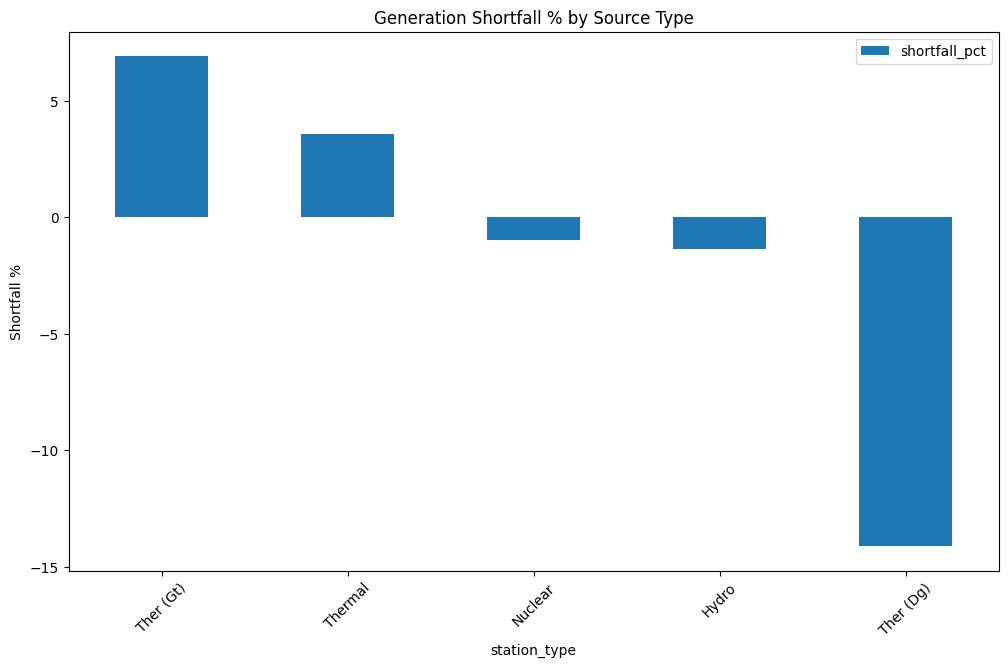

In [17]:
source_reliability.plot(kind = 'bar', x='station_type', y='shortfall_pct', figsize=(12,7))
plt.title('Generation Shortfall % by Source Type')
plt.ylabel('Shortfall %')
plt.xticks(rotation=45)
plt.show()

In [18]:
state_monthly['month'] = state_monthly['year_month'].dt.month
seasonal = state_monthly.groupby('month').agg(
    total_prgm = ('total_prgm', 'sum'),
    total_act = ('total_act', 'sum'),
    total_shortfall = ('total_shortfall', 'sum'),
).reset_index()
seasonal['shortfall_pct'] = (seasonal['total_shortfall'] / seasonal['total_prgm']) * 100

print("=== INSIGHT 4: Seasonal shortfall pattern (all years combined) ===")
print(seasonal[['month', 'shortfall_pct']].to_string(index=False))
worst_month = seasonal.loc[seasonal['shortfall_pct'].idxmax(), 'month']
print(f"-> Highest average shortfall occurs in month {worst_month}\n")

=== INSIGHT 4: Seasonal shortfall pattern (all years combined) ===
 month  shortfall_pct
     1       1.243610
     2       1.224766
     3       1.545760
     4       3.207472
     5       3.175536
     6       4.185456
     7       2.820795
     8       5.046922
     9       4.060789
    10       1.978596
    11       4.537078
    12       2.896698
-> Highest average shortfall occurs in month 8



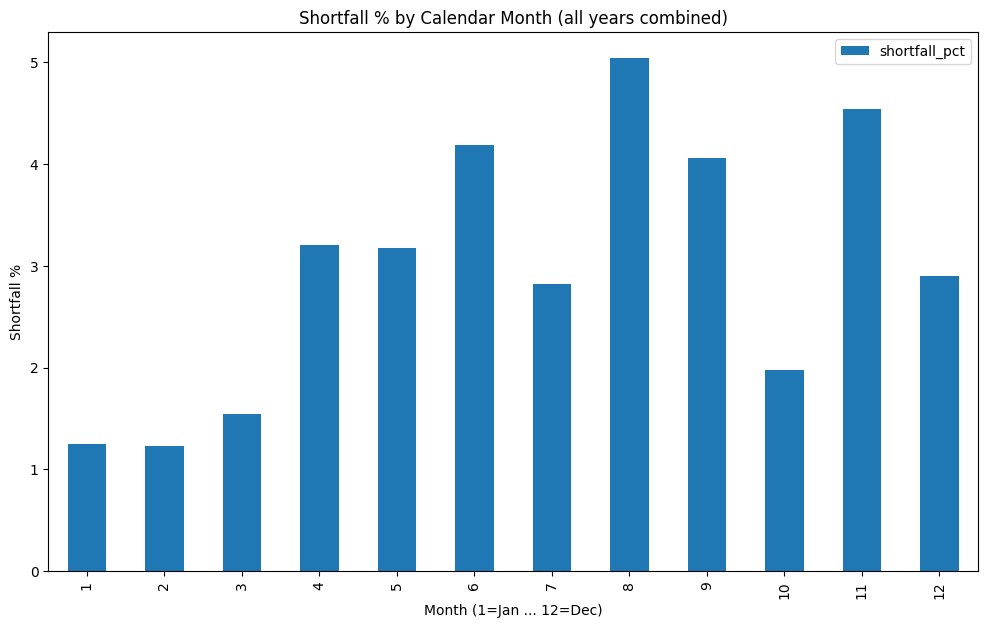

In [19]:
seasonal.plot(kind='bar', x='month', y='shortfall_pct', figsize=(12,7))
plt.title('Shortfall % by Calendar Month (all years combined)')
plt.ylabel('Shortfall %')
plt.xlabel('Month (1=Jan ... 12=Dec)')
plt.show()

In [21]:
df.to_csv('india_power_cleaned_unit_level.csv', index=False)
state_monthly.to_csv('india_power_state_monthly.csv', index=False)
statetype_monthly.to_csv('india_power_statetype_monthly.csv', index=False)
bhutan_import.to_csv('india_power_bhutan_imports.csv', index=False)